In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned_flights.csv")

print(df.shape)
df.head()

(499999, 13)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_HOUR,SCHEDULED_TIME,DISTANCE,IS_WEEKEND,DELAYED
0,2015,3,8,7,WN,MCI,MDW,1505,15,80.0,405,1,1
1,2015,5,3,7,WN,DAL,MCI,1735,17,85.0,460,1,0
2,2015,4,3,5,WN,RSW,CMH,1445,14,150.0,930,0,0
3,2015,3,28,6,OO,GTF,DEN,1458,14,114.0,624,1,1
4,2015,9,6,7,WN,ATL,MCO,1635,16,90.0,404,1,0


In [2]:
features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "DEPARTURE_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "IS_WEEKEND"
]

target = "DELAYED"

X = df[features]
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (499999, 10)
Target: (499999,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (399999, 10)
Testing: (100000, 10)


In [4]:
categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

In [5]:
numeric_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "DEPARTURE_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "IS_WEEKEND"
]

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [7]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (399999, 10)
Testing: (100000, 10)


In [8]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training: (399999, 10)
Testing: (100000, 10)

Training class distribution:
DELAYED
0    0.815455
1    0.184545
Name: proportion, dtype: float64

Testing class distribution:
DELAYED
0    0.81545
1    0.18455
Name: proportion, dtype: float64


In [9]:
print("Logistic Regression trained!")

Logistic Regression trained!


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

NameError: name 'logistic_model' is not defined

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

numeric_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "DEPARTURE_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "IS_WEEKEND"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

In [12]:
print(X_train.shape)
print(X_test.shape)

(399999, 10)
(100000, 10)


In [17]:
logistic_model.fit(X_train, y_train)
print("Logistic Regression trained!")

Logistic Regression trained!


/home/sankar/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.61786
Precision: 0.26884110531364797
Recall   : 0.6225955025738282
F1 Score : 0.3755270124522012
ROC-AUC  : 0.661740661116966


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=200,
            class_weight="balanced",
            solver="saga",
            random_state=42
        )
    )
])

In [20]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


/home/sankar/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.5822
Precision: 0.2501
Recall   : 0.6325
F1 Score : 0.3584
ROC-AUC  : 0.6343


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Random Forest model created!")

Random Forest model created!


In [23]:
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [24]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")

print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob), 4))

Random Forest Results
---------------------
Accuracy : 0.6155
Precision: 0.2721
Recall   : 0.6465
F1 Score : 0.383
ROC-AUC  : 0.6751


In [26]:
import matplotlib.pyplot as plt

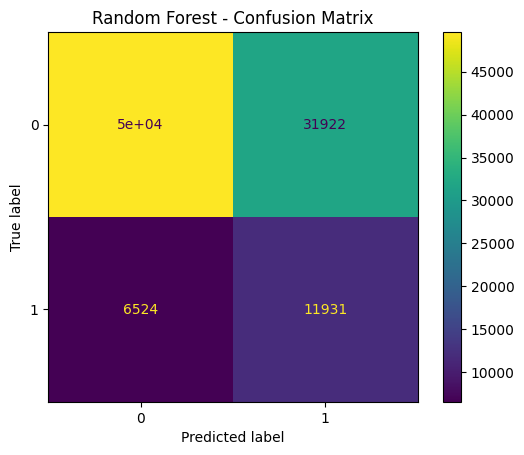

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [28]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

results = pd.DataFrame([
    logistic_results,
    rf_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.58218,0.250091,0.632457,0.358444,0.634316
1,Random Forest,0.61554,0.272068,0.646491,0.382968,0.675125


In [37]:
import xgboost
print(xgboost.__version__)


3.2.0


In [38]:
from xgboost import XGBClassifier

In [39]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [40]:
xgb_model.fit(X_train, y_train)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:AIRLINE: object, ORIGIN_AIRPORT: object, DESTINATION_AIRPORT: object

In [41]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

categorical_columns = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

for col in categorical_columns:
    X_train_xgb[col] = X_train_xgb[col].astype("category")
    X_test_xgb[col] = X_test_xgb[col].astype("category")

In [42]:
for col in categorical_columns:
    categories = X_train_xgb[col].cat.categories

    X_train_xgb[col] = X_train_xgb[col].cat.codes

    X_test_xgb[col] = (
        pd.Categorical(
            X_test_xgb[col],
            categories=categories
        ).codes
    )

In [43]:
X_train_xgb.dtypes

AIRLINE                   int8
ORIGIN_AIRPORT           int16
DESTINATION_AIRPORT      int16
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
DEPARTURE_HOUR           int64
SCHEDULED_TIME         float64
DISTANCE                 int64
IS_WEEKEND               int64
dtype: object

In [44]:
xgb_model.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [45]:
xgb_pred = xgb_model.predict(X_test_xgb)
xgb_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]

In [46]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.81952,
 'Precision': 0.6260061919504644,
 'Recall': 0.05478190192359794,
 'F1': 0.10074738415545591,
 'ROC-AUC': np.float64(0.718069524252723)}

In [47]:
results = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.58218,0.250091,0.632457,0.358444,0.634316
1,Random Forest,0.61554,0.272068,0.646491,0.382968,0.675125
2,XGBoost,0.81952,0.626006,0.054782,0.100747,0.718070


In [48]:
print("Training set:")
print(y_train.value_counts())

print("\nTest set:")
print(y_test.value_counts())

print("\nTraining percentages:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest percentages:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
DELAYED
0    326181
1     73818
Name: count, dtype: int64

Test set:
DELAYED
0    81545
1    18455
Name: count, dtype: int64

Training percentages:
DELAYED
0    81.545454
1    18.454546
Name: proportion, dtype: float64

Test percentages:
DELAYED
0    81.545
1    18.455
Name: proportion, dtype: float64


In [49]:
# Calculate class weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 4.418719011623181


In [50]:
from xgboost import XGBClassifier

xgb_balanced = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_balanced.fit(X_train_xgb, y_train)

print("Balanced XGBoost training completed successfully!")

Balanced XGBoost training completed successfully!


In [51]:
# Make predictions using balanced XGBoost

xgb_balanced_pred = xgb_balanced.predict(X_test_xgb)
xgb_balanced_prob = xgb_balanced.predict_proba(X_test_xgb)[:, 1]

print("Predictions completed successfully!")

Predictions completed successfully!


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

balanced_accuracy = accuracy_score(y_test, xgb_balanced_pred)
balanced_precision = precision_score(y_test, xgb_balanced_pred)
balanced_recall = recall_score(y_test, xgb_balanced_pred)
balanced_f1 = f1_score(y_test, xgb_balanced_pred)
balanced_roc_auc = roc_auc_score(y_test, xgb_balanced_prob)

print("Balanced XGBoost Results")
print("------------------------")
print("Accuracy :", balanced_accuracy)
print("Precision:", balanced_precision)
print("Recall   :", balanced_recall)
print("F1 Score :", balanced_f1)
print("ROC-AUC  :", balanced_roc_auc)


Balanced XGBoost Results
------------------------
Accuracy : 0.65799
Precision: 0.3038126090206828
Recall   : 0.6606339745326469
F1 Score : 0.416215754886063
ROC-AUC  : 0.7174723319134118


Confusion Matrix:
[[53607 27938]
 [ 6263 12192]]


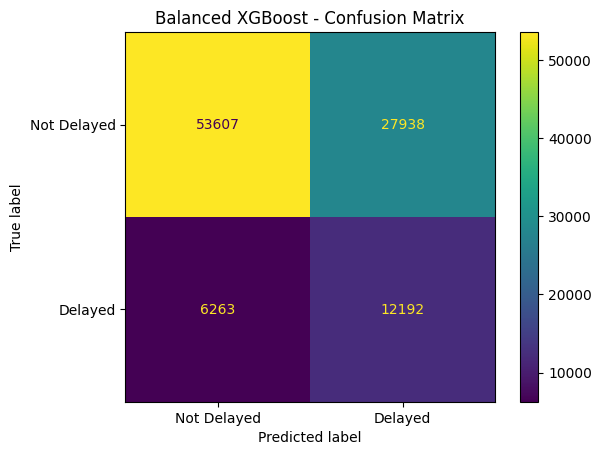

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_balanced_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Delayed", "Delayed"]
)

disp.plot()
plt.title("Balanced XGBoost - Confusion Matrix")
plt.show()

Top 15 Important Features:
DEPARTURE_HOUR         0.379938
MONTH                  0.139010
AIRLINE                0.131421
DAY                    0.082346
DAY_OF_WEEK            0.066439
ORIGIN_AIRPORT         0.058817
DISTANCE               0.050507
DESTINATION_AIRPORT    0.047449
SCHEDULED_TIME         0.044075
IS_WEEKEND             0.000000
dtype: float32


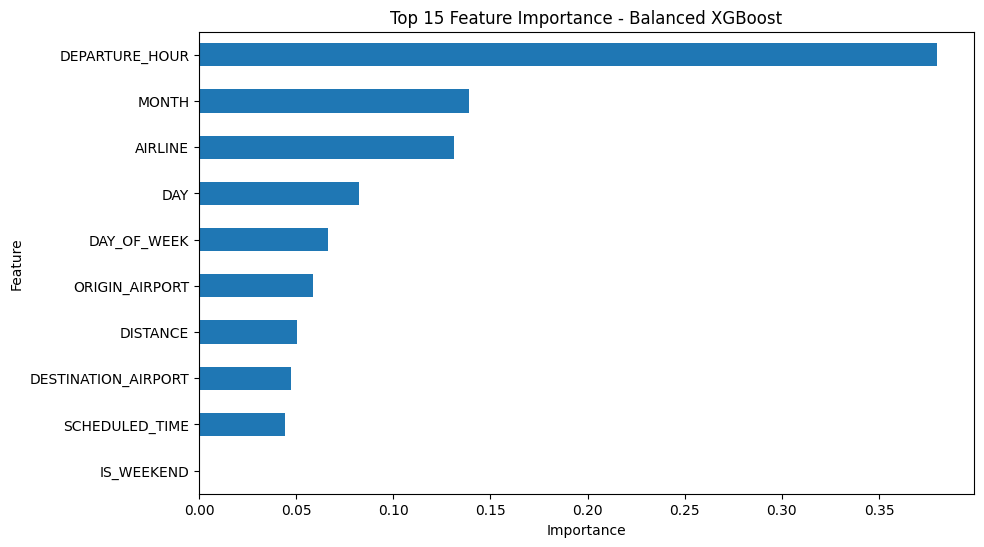

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    xgb_balanced.feature_importances_,
    index=X_train_xgb.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

feature_importance.head(15).plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 15 Feature Importance - Balanced XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [55]:
xgb_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_tuned.fit(X_train_xgb, y_train)

print("Tuned XGBoost training completed successfully!")

Tuned XGBoost training completed successfully!


In [56]:
xgb_tuned_pred = xgb_tuned.predict(X_test_xgb)
xgb_tuned_prob = xgb_tuned.predict_proba(X_test_xgb)[:, 1]

print("Tuned XGBoost predictions completed successfully!")

Tuned XGBoost predictions completed successfully!


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

tuned_accuracy = accuracy_score(y_test, xgb_tuned_pred)
tuned_precision = precision_score(y_test, xgb_tuned_pred)
tuned_recall = recall_score(y_test, xgb_tuned_pred)
tuned_f1 = f1_score(y_test, xgb_tuned_pred)
tuned_roc_auc = roc_auc_score(y_test, xgb_tuned_prob)

print("Tuned XGBoost Results")
print("---------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)
print("ROC-AUC  :", tuned_roc_auc)


Tuned XGBoost Results
---------------------
Accuracy : 0.64438
Precision: 0.29508157447114347
Recall   : 0.6674072067190463
F1 Score : 0.4092298491594126
ROC-AUC  : 0.7095110041163677


In [58]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

print("Threshold | Precision | Recall | F1 Score")
print("-------------------------------------------")

for threshold in thresholds:
    predictions = (xgb_balanced_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(
        f"{threshold:8.2f} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f} | "
        f"{f1:8.4f}"
    )


Threshold | Precision | Recall | F1 Score
-------------------------------------------
    0.20 |    0.1965 | 0.9820 |   0.3275
    0.25 |    0.2066 | 0.9604 |   0.3401
    0.30 |    0.2193 | 0.9279 |   0.3547
    0.35 |    0.2343 | 0.8804 |   0.3701
    0.40 |    0.2534 | 0.8195 |   0.3871
    0.45 |    0.2766 | 0.7472 |   0.4037
    0.50 |    0.3038 | 0.6606 |   0.4162
    0.55 |    0.3370 | 0.5596 |   0.4207
    0.60 |    0.3741 | 0.4471 |   0.4073


In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_threshold = 0.55

xgb_final_pred = (xgb_balanced_prob >= best_threshold).astype(int)

final_accuracy = accuracy_score(y_test, xgb_final_pred)
final_precision = precision_score(y_test, xgb_final_pred)
final_recall = recall_score(y_test, xgb_final_pred)
final_f1 = f1_score(y_test, xgb_final_pred)

print("Final XGBoost Threshold Results")
print("--------------------------------")
print("Threshold :", best_threshold)
print("Accuracy  :", final_accuracy)
print("Precision :", final_precision)
print("Recall    :", final_recall)
print("F1 Score  :", final_f1)

Final XGBoost Threshold Results
--------------------------------
Threshold : 0.55
Accuracy  : 0.71555
Precision : 0.3370097239443973
Recall    : 0.5596315361690599
F1 Score  : 0.4206838964583206


Final Confusion Matrix:
[[61227 20318]
 [ 8127 10328]]


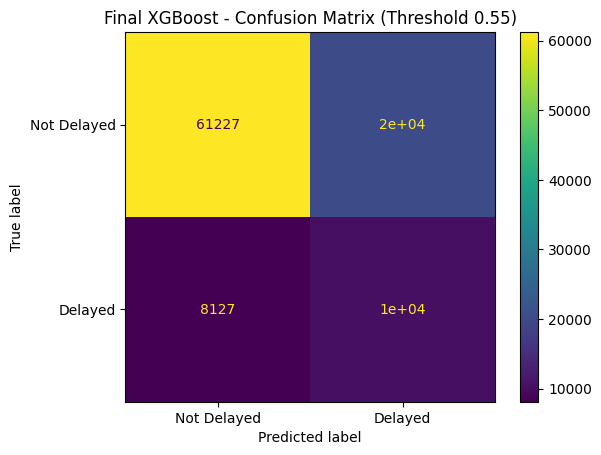

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_cm = confusion_matrix(y_test, xgb_final_pred)

print("Final Confusion Matrix:")
print(final_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Not Delayed", "Delayed"]
)

disp.plot()
plt.title("Final XGBoost - Confusion Matrix (Threshold 0.55)")
plt.show()

In [61]:
print("TN (Correctly Not Delayed):", final_cm[0, 0])
print("FP (Incorrectly Predicted Delayed):", final_cm[0, 1])
print("FN (Missed Delayed Flight):", final_cm[1, 0])
print("TP (Correctly Predicted Delayed):", final_cm[1, 1])

TN (Correctly Not Delayed): 61227
FP (Incorrectly Predicted Delayed): 20318
FN (Missed Delayed Flight): 8127
TP (Correctly Predicted Delayed): 10328


In [62]:
import joblib
import os

# Create models folder
os.makedirs("/home/sankar/Documents/Flight-delay-prediction/models", exist_ok=True)

# Save the trained XGBoost model
joblib.dump(
    xgb_balanced,
    "/home/sankar/Documents/Flight-delay-prediction/models/flight_delay_xgboost.pkl"
)

# Save the prediction threshold
joblib.dump(
    best_threshold,
    "/home/sankar/Documents/Flight-delay-prediction/models/threshold.pkl"
)

print("Final model saved successfully!")
print("Model: flight_delay_xgboost.pkl")
print("Threshold: threshold.pkl")

Final model saved successfully!
Model: flight_delay_xgboost.pkl
Threshold: threshold.pkl


In [63]:
import joblib

# Load the saved model
loaded_model = joblib.load(
    "/home/sankar/Documents/Flight-delay-prediction/models/flight_delay_xgboost.pkl"
)

# Load the saved threshold
loaded_threshold = joblib.load(
    "/home/sankar/Documents/Flight-delay-prediction/models/threshold.pkl"
)

print("Model loaded successfully!")
print("Threshold loaded successfully!")
print("Prediction threshold:", loaded_threshold)

Model loaded successfully!
Threshold loaded successfully!
Prediction threshold: 0.55


In [64]:
print("Number of features:", len(X_train_xgb.columns))
print("\nFeatures used by the model:")
print(list(X_train_xgb.columns))

Number of features: 10

Features used by the model:
['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'DEPARTURE_HOUR', 'SCHEDULED_TIME', 'DISTANCE', 'IS_WEEKEND']


In [65]:
# Save the category mappings used during XGBoost training

category_mappings = {}

for col in ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]:
    category_mappings[col] = X_train[col].astype("category").cat.categories.tolist()

joblib.dump(
    category_mappings,
    "/home/sankar/Documents/Flight-delay-prediction/models/category_mappings.pkl"
)

print("Category mappings saved successfully!")

for col, categories in category_mappings.items():
    print(f"{col}: {len(categories)} categories")

Category mappings saved successfully!
AIRLINE: 14 categories
ORIGIN_AIRPORT: 623 categories
DESTINATION_AIRPORT: 624 categories


In [66]:
import pandas as pd
import joblib

# Load saved files
model = joblib.load(
    "/home/sankar/Documents/Flight-delay-prediction/models/flight_delay_xgboost.pkl"
)

threshold = joblib.load(
    "/home/sankar/Documents/Flight-delay-prediction/models/threshold.pkl"
)

category_mappings = joblib.load(
    "/home/sankar/Documents/Flight-delay-prediction/models/category_mappings.pkl"
)


def predict_flight_delay(
    airline,
    origin_airport,
    destination_airport,
    month,
    day,
    day_of_week,
    departure_hour,
    scheduled_time,
    distance,
    is_weekend
):

    # Check categorical values
    if airline not in category_mappings["AIRLINE"]:
        return f"Unknown airline: {airline}"

    if origin_airport not in category_mappings["ORIGIN_AIRPORT"]:
        return f"Unknown origin airport: {origin_airport}"

    if destination_airport not in category_mappings["DESTINATION_AIRPORT"]:
        return f"Unknown destination airport: {destination_airport}"

    # Convert categorical values to the SAME codes used during training
    airline_code = category_mappings["AIRLINE"].index(airline)
    origin_code = category_mappings["ORIGIN_AIRPORT"].index(origin_airport)
    destination_code = category_mappings["DESTINATION_AIRPORT"].index(destination_airport)

    # Create input data in EXACT training feature order
    input_data = pd.DataFrame([{
        "AIRLINE": airline_code,
        "ORIGIN_AIRPORT": origin_code,
        "DESTINATION_AIRPORT": destination_code,
        "MONTH": month,
        "DAY": day,
        "DAY_OF_WEEK": day_of_week,
        "DEPARTURE_HOUR": departure_hour,
        "SCHEDULED_TIME": scheduled_time,
        "DISTANCE": distance,
        "IS_WEEKEND": is_weekend
    }])

    # Get probability of delay
    probability = model.predict_proba(input_data)[0][1]

    # Apply threshold
    prediction = int(probability >= threshold)

    if prediction == 1:
        result = "DELAYED"
    else:
        result = "NOT DELAYED"

    return {
        "prediction": result,
        "delay_probability": round(probability * 100, 2),
        "threshold": threshold
    }


print("Prediction function created successfully!")

Prediction function created successfully!


In [67]:
result = predict_flight_delay(
    airline="AA",
    origin_airport="JFK",
    destination_airport="LAX",
    month=6,
    day=15,
    day_of_week=1,
    departure_hour=8,
    scheduled_time=360,
    distance=2475,
    is_weekend=0
)

print(result)

{'prediction': 'NOT DELAYED', 'delay_probability': np.float32(43.95), 'threshold': 0.55}


In [68]:
result = predict_flight_delay(
    airline="DL",
    origin_airport="ATL",
    destination_airport="LAX",
    month=7,
    day=20,
    day_of_week=1,
    departure_hour=18,
    scheduled_time=250,
    distance=1946,
    is_weekend=0
)

print(result)


{'prediction': 'DELAYED', 'delay_probability': np.float32(61.36), 'threshold': 0.55}


In [69]:
test_flights = [
    {
        "airline": "AA",
        "origin": "JFK",
        "destination": "LAX",
        "month": 6,
        "day": 15,
        "day_of_week": 1,
        "departure_hour": 8,
        "scheduled_time": 360,
        "distance": 2475,
        "is_weekend": 0
    },
    {
        "airline": "DL",
        "origin": "ATL",
        "destination": "LAX",
        "month": 7,
        "day": 20,
        "day_of_week": 1,
        "departure_hour": 18,
        "scheduled_time": 250,
        "distance": 1946,
        "is_weekend": 0
    },
    {
        "airline": "UA",
        "origin": "ORD",
        "destination": "LAX",
        "month": 8,
        "day": 10,
        "day_of_week": 1,
        "departure_hour": 20,
        "scheduled_time": 260,
        "distance": 1744,
        "is_weekend": 0
    },
    {
        "airline": "AA",
        "origin": "DFW",
        "destination": "JFK",
        "month": 12,
        "day": 24,
        "day_of_week": 4,
        "departure_hour": 17,
        "scheduled_time": 210,
        "distance": 1391,
        "is_weekend": 0
    },
    {
        "airline": "DL",
        "origin": "ATL",
        "destination": "JFK",
        "month": 1,
        "day": 3,
        "day_of_week": 6,
        "departure_hour": 10,
        "scheduled_time": 130,
        "distance": 760,
        "is_weekend": 1
    }
]

for i, flight in enumerate(test_flights, start=1):

    result = predict_flight_delay(
        airline=flight["airline"],
        origin_airport=flight["origin"],
        destination_airport=flight["destination"],
        month=flight["month"],
        day=flight["day"],
        day_of_week=flight["day_of_week"],
        departure_hour=flight["departure_hour"],
        scheduled_time=flight["scheduled_time"],
        distance=flight["distance"],
        is_weekend=flight["is_weekend"]
    )

    print(f"Flight {i}:")
    print(result)
    print("-" * 50)

Flight 1:
{'prediction': 'NOT DELAYED', 'delay_probability': np.float32(43.95), 'threshold': 0.55}
--------------------------------------------------
Flight 2:
{'prediction': 'DELAYED', 'delay_probability': np.float32(61.36), 'threshold': 0.55}
--------------------------------------------------
Flight 3:
{'prediction': 'DELAYED', 'delay_probability': np.float32(84.87), 'threshold': 0.55}
--------------------------------------------------
Flight 4:
{'prediction': 'NOT DELAYED', 'delay_probability': np.float32(46.09), 'threshold': 0.55}
--------------------------------------------------
Flight 5:
{'prediction': 'DELAYED', 'delay_probability': np.float32(61.09), 'threshold': 0.55}
--------------------------------------------------


In [71]:
print("✈️ FLIGHT DELAY PREDICTION")
print("=" * 40)

airline = input("Enter airline code (example: AA): ")
origin = input("Enter origin airport (example: JFK): ")
destination = input("Enter destination airport (example: LAX): ")

month = int(input("Enter month (1-12): "))
day = int(input("Enter day (1-31): "))
day_of_week = int(input("Enter day of week (0=Monday, 6=Sunday): "))

departure_hour = int(input("Enter departure hour (0-23): "))
scheduled_time = int(input("Enter scheduled time in minutes: "))
distance = int(input("Enter distance in miles: "))

is_weekend = int(input("Is it weekend? (1=Yes, 0=No): "))

result = predict_flight_delay(
    airline=airline,
    origin_airport=origin,
    destination_airport=destination,
    month=month,
    day=day,
    day_of_week=day_of_week,
    departure_hour=departure_hour,
    scheduled_time=scheduled_time,
    distance=distance,
    is_weekend=is_weekend
)

print("\n" + "=" * 40)
print("PREDICTION RESULT")
print("=" * 40)
print(result)

✈️ FLIGHT DELAY PREDICTION


Enter airline code (example: AA):  DL
Enter origin airport (example: JFK):  ATL
Enter destination airport (example: LAX):  JFK
Enter month (1-12):  1
Enter day (1-31):  3
Enter day of week (0=Monday, 6=Sunday):  6
Enter departure hour (0-23):  10
Enter scheduled time in minutes:  130
Enter distance in miles:  760
Is it weekend? (1=Yes, 0=No):  1



PREDICTION RESULT
{'prediction': 'DELAYED', 'delay_probability': np.float32(61.09), 'threshold': 0.55}


In [72]:
import os

model_folder = "/home/sankar/Documents/Flight-delay-prediction/models"

print("Saved model files:")
print("=" * 40)

for file in os.listdir(model_folder):
    print("✅", file)
    

Saved model files:
✅ flight_delay_xgboost.pkl
✅ threshold.pkl
✅ category_mappings.pkl


In [73]:
import os

model_folder = "/home/sankar/Documents/Flight-delay-prediction/models"

print("Saved model files:")
print("=" * 40)

for file in os.listdir(model_folder):
    print("✅", file)

Saved model files:
✅ flight_delay_xgboost.pkl
✅ threshold.pkl
✅ category_mappings.pkl
